In [142]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [143]:
df = pd.read_csv('loan_approval_data.csv')

In [144]:
# df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handle the Missing Values 

In [145]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [146]:
num_imputer = SimpleImputer(strategy='mean')
numerical_cols = num_imputer.fit_transform(df[numerical_cols])

In [147]:
cat_imputer = SimpleImputer(strategy='most_frequent')
categorical_cols = cat_imputer.fit_transform(df[categorical_cols])

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Exploratory Data Analysis

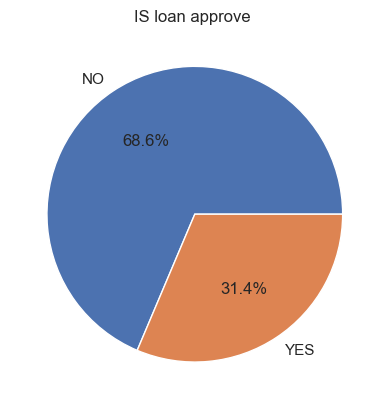

In [149]:
# Is Our class is balance 

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["NO", "YES"], autopct='%1.1f%%')
plt.title("IS loan approve ")
plt.show()

[Text(0, 0, '571'), Text(0, 0, '379')]

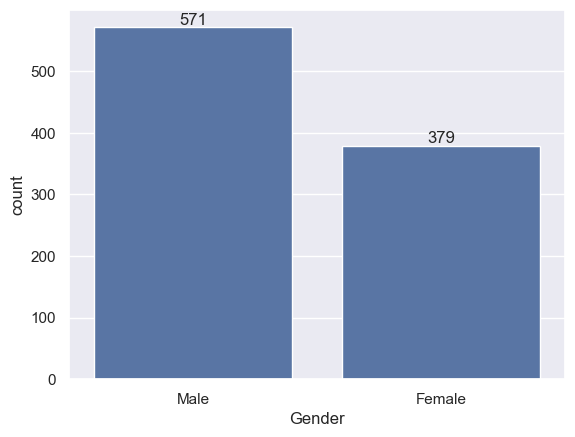

In [150]:
Gender_count = df['Gender'].value_counts()
ax = sns.barplot(Gender_count)
ax.bar_label(ax.containers[0])

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

[Text(0, 0, '672'), Text(0, 0, '278')]

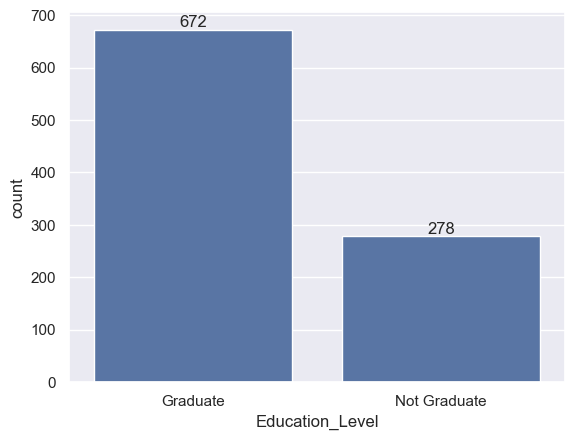

In [152]:
Edu_level_count = df['Education_Level'].value_counts()
ax = sns.barplot(Edu_level_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '372'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

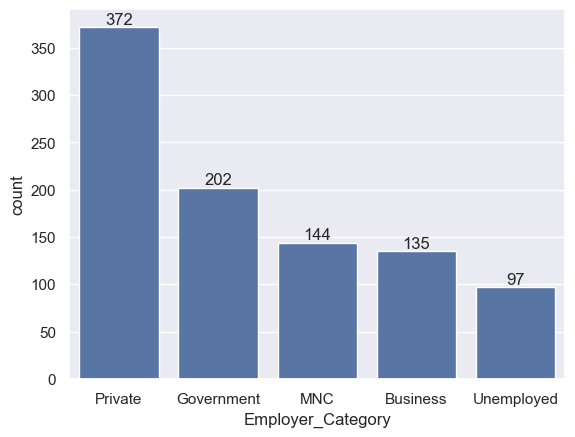

In [153]:
Employer_type_count = df['Employer_Category'].value_counts()
ax = sns.barplot(Employer_type_count)
ax.bar_label(ax.containers[0])

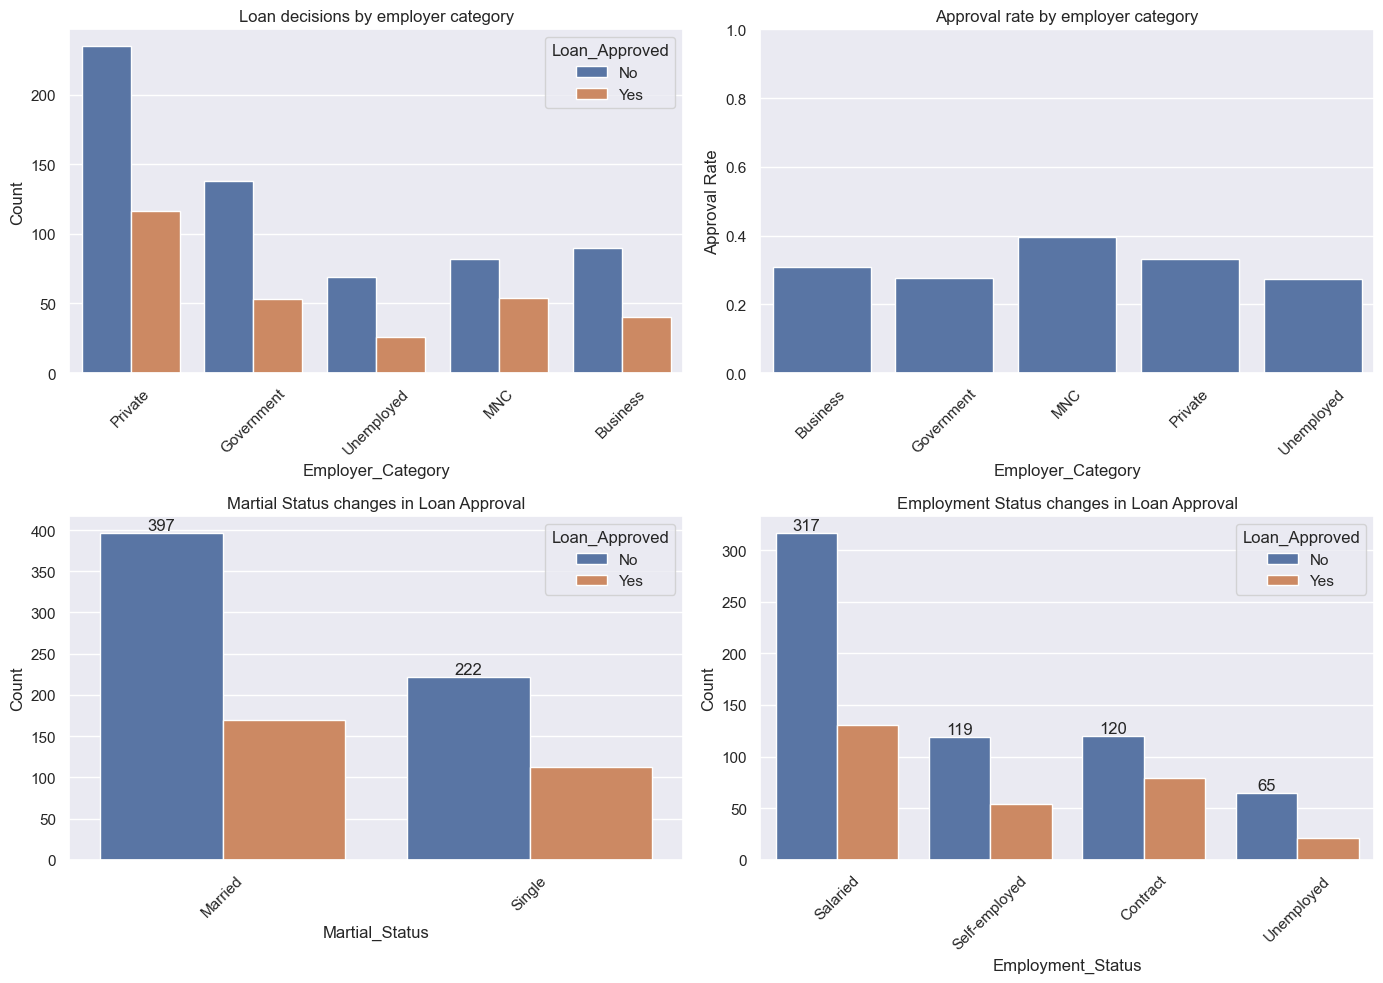

In [154]:
# Relationship between Employer_Category and Loan_Approved
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Count of approvals/denials per employer category
sns.countplot(data=df, x='Employer_Category', hue='Loan_Approved', ax=axes[0][0])
axes[0][0].set_title('Loan decisions by employer category')
axes[0][0].set_xlabel('Employer_Category')
axes[0][0].set_ylabel('Count')
axes[0][0].tick_params(axis='x', rotation=45)

# Approval rate per employer category (Yes=1, No=0)
approval_rate = (
    df.assign(Loan_Approved_Flag=df['Loan_Approved'].map({'Yes': 1, 'No': 0}))
      .groupby('Employer_Category')['Loan_Approved_Flag']
      .mean()
      .reset_index()
)
sns.barplot(data=approval_rate, x='Employer_Category', y='Loan_Approved_Flag', ax=axes[0][1])
axes[0][1].set_title('Approval rate by employer category')
axes[0][1].set_xlabel('Employer_Category')
axes[0][1].set_ylabel('Approval Rate')
axes[0][1].tick_params(axis='x', rotation=45)
axes[0][1].set_ylim(0, 1)

sns.countplot(data=df, x='Marital_Status', hue='Loan_Approved', ax=axes[1][0])
axes[1][0].set_title('Martial Status changes in Loan Approval')
axes[1][0].set_xlabel('Martial_Status')
axes[1][0].set_ylabel('Count')
axes[1][0].bar_label(axes[1][0].containers[0])
axes[1][0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Employment_Status', hue='Loan_Approved', ax=axes[1][1])
axes[1][1].set_title('Employment Status changes in Loan Approval')
axes[1][1].set_xlabel('Employment_Status')
axes[1][1].set_ylabel('Count')
axes[1][1].bar_label(axes[1][1].containers[0])
axes[1][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

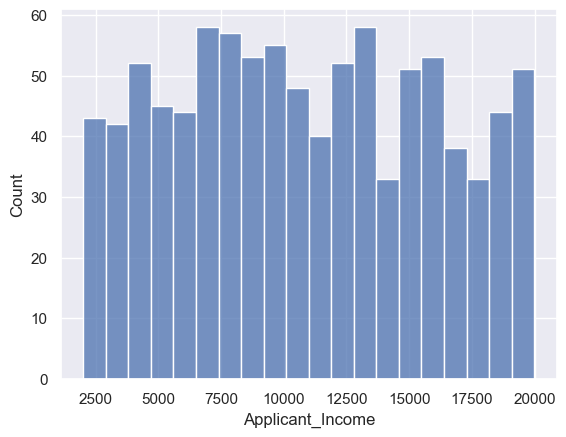

In [155]:
sns.histplot(
    data=df,
    x='Applicant_Income',bins=20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

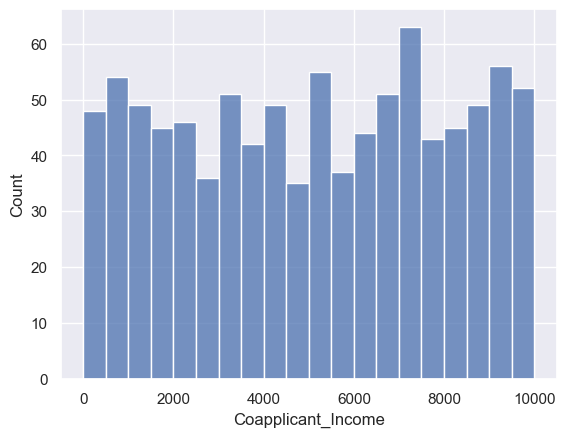

In [156]:
sns.histplot(
    data=df,
    x='Coapplicant_Income',bins=20)

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Text(0.5, 1.0, 'Loan Term')

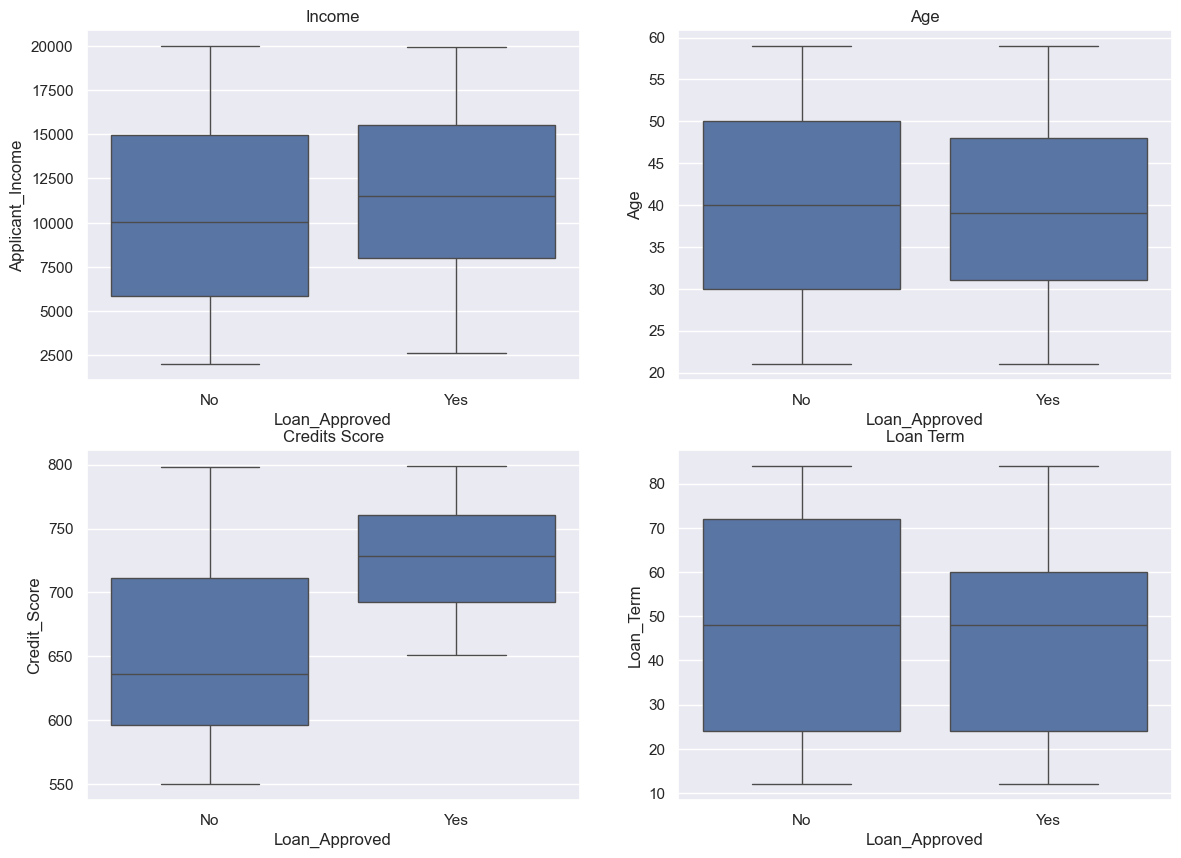

In [158]:
sns.set_theme(style="darkgrid")

# box plot 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(
    data=df,
    x='Loan_Approved',
    y='Applicant_Income',
    ax=axes[0][0]
)
axes[0][0].set_title("Income")
sns.boxplot(
    data=df,
    x='Loan_Approved',
    y='Age',
    ax=axes[0][1]
)
axes[0][1].set_title("Age")

sns.boxplot(
    data=df,
    x='Loan_Approved',
    y='Credit_Score',
    ax=axes[1][0]
)
           
axes[1][0].set_title("Credits Score")

sns.boxplot(
    data=df,
    x='Loan_Approved',
    y='Loan_Term',
    ax=axes[1][1]
)
axes[1][1].set_title("Loan Term")


# remove the applicant id 


In [159]:
df= df.drop('Applicant_ID',axis=1)

In [160]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# Feature Encoding

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    950 non-null    float64
 1   Coapplicant_Income  950 non-null    float64
 2   Employment_Status   950 non-null    object 
 3   Age                 950 non-null    float64
 4   Marital_Status      950 non-null    object 
 5   Dependents          950 non-null    float64
 6   Credit_Score        950 non-null    float64
 7   Existing_Loans      950 non-null    float64
 8   DTI_Ratio           950 non-null    float64
 9   Savings             950 non-null    float64
 10  Collateral_Value    950 non-null    float64
 11  Loan_Amount         950 non-null    float64
 12  Loan_Term           950 non-null    float64
 13  Loan_Purpose        950 non-null    object 
 14  Property_Area       950 non-null    object 
 15  Education_Level     950 non-null    object 
 16  Gender 

In [162]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# LabelEncoder - for ordinal/binary categorical columns using the ordered data ,mean 0,1,2,etc level wise data with meaning  using gender , employement field
# OneHotEncoder - for nominal categorical columns with multiple categories for not order
LE = LabelEncoder()
 
df['Education_Level']  = LE.fit_transform(df['Education_Level'])   
 
df['Loan_Approved']  = LE.fit_transform(df['Loan_Approved'])   
# Loan_Approved       




In [163]:
OH = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

cols = ['Marital_Status','Loan_Purpose','Employment_Status','Gender','Property_Area','Employer_Category']
encoded = OH.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded,columns=OH.get_feature_names_out(cols),index= df.index)

In [164]:
OH.get_feature_names_out(cols)

array(['Marital_Status_Single', 'Marital_Status_nan', 'Loan_Purpose_Car',
       'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Loan_Purpose_nan',
       'Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Employment_Status_nan',
       'Gender_Male', 'Gender_nan', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Property_Area_nan',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed',
       'Employer_Category_nan'], dtype=object)

In [165]:
#  = pd.DataFrame(encoded, columns=OH.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Gender_Male,Gender_nan,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,9092.0,58.0,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
996,3279.0,6356.0,58.0,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
997,15192.0,8433.0,48.0,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
998,9083.0,7380.0,50.0,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 950 non-null    float64
 1   Coapplicant_Income               950 non-null    float64
 2   Age                              950 non-null    float64
 3   Dependents                       950 non-null    float64
 4   Credit_Score                     950 non-null    float64
 5   Existing_Loans                   950 non-null    float64
 6   DTI_Ratio                        950 non-null    float64
 7   Savings                          950 non-null    float64
 8   Collateral_Value                 950 non-null    float64
 9   Loan_Amount                      950 non-null    float64
 10  Loan_Term                        950 non-null    float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation HeatMap

In [167]:
nums_col = df.select_dtypes(include='number')
corr_matrix = nums_col.corr()

nums_col.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.404817
Applicant_Income                   0.099770
Employer_Category_MNC              0.062015
Marital_Status_Single              0.053416
Collateral_Value                   0.040321
Employment_Status_nan              0.040155
Loan_Purpose_nan                   0.040155
Employer_Category_Private          0.035304
Gender_nan                         0.032282
Loan_Purpose_Personal              0.027617
Coapplicant_Income                 0.026428
Dependents                         0.022332
Loan_Purpose_Education             0.013201
Property_Area_Urban                0.010779
Property_Area_nan                  0.008661
Loan_Purpose_Home                  0.006036
Employment_Status_Self-employed   -0.001939
Marital_Status_nan                -0.007086
Property_Area_Semiurban           -0.014122
Education_Level                   -0.019102
Gender_Male                       -0.021697
Employer_Category_Government    

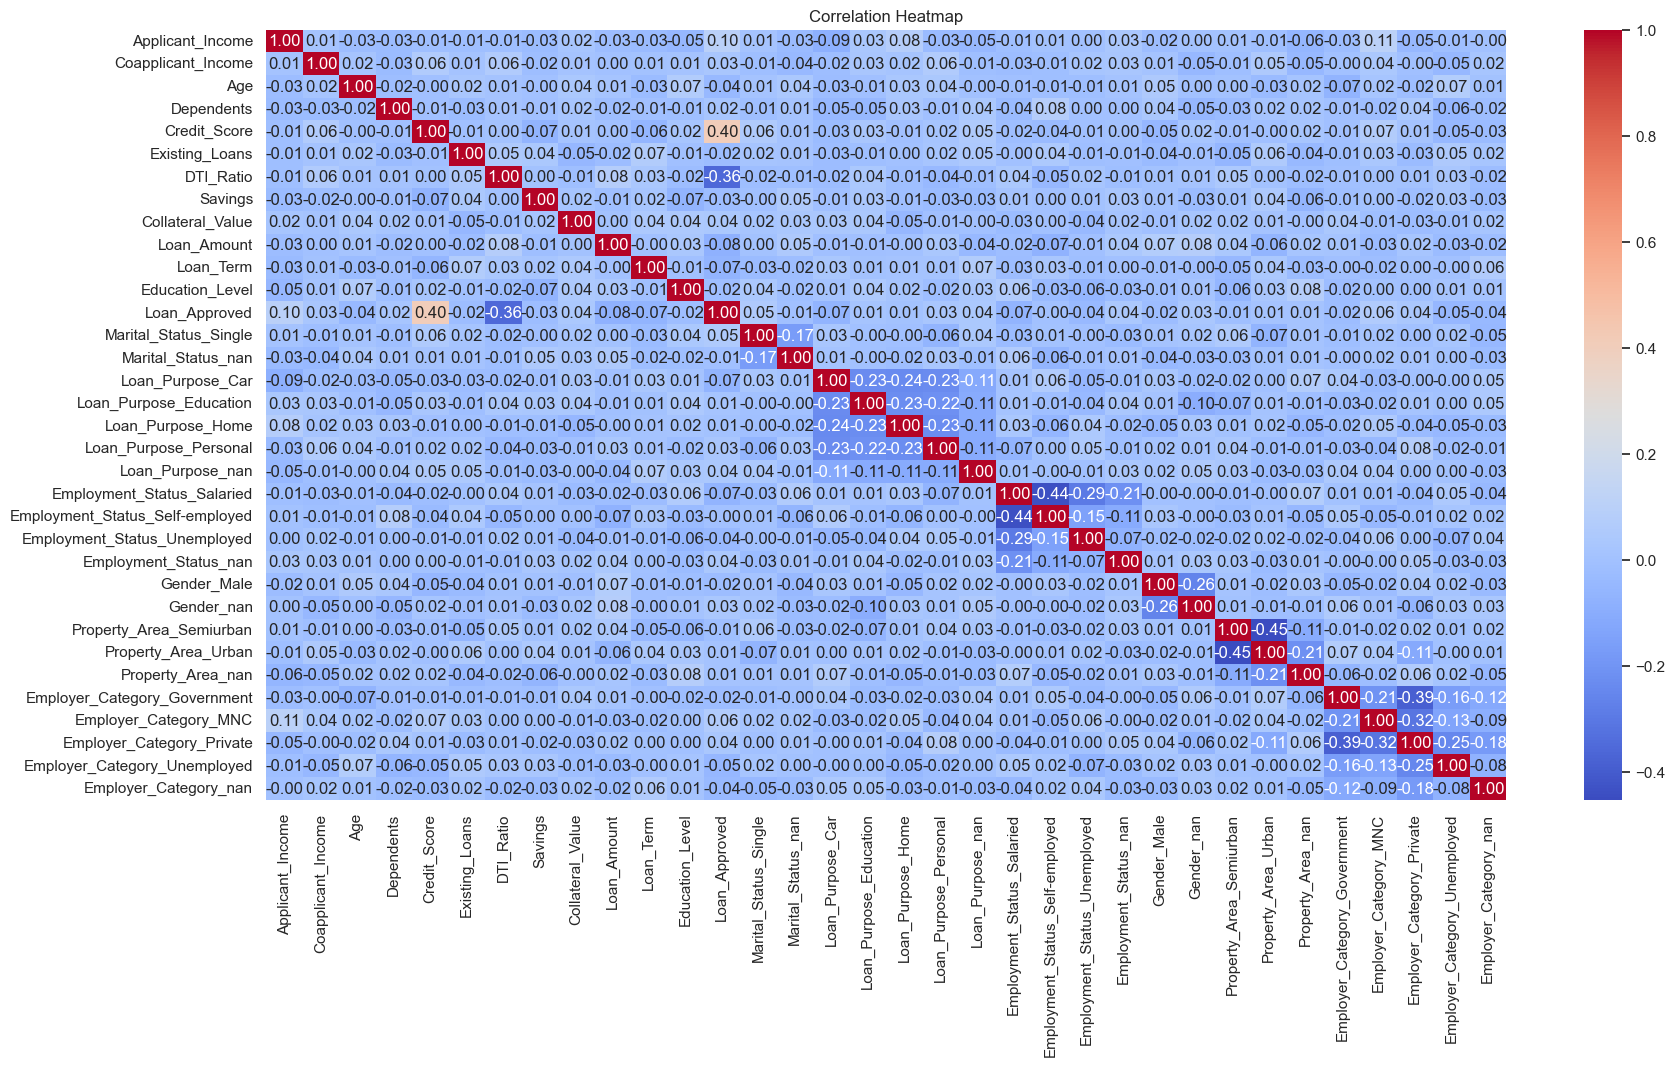

In [ ]:
# sns.cubehelix_palette(as_cmap=True)
corr_matrix

plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt= ".2f",
            cmap='coolwarm'
             )
plt.title("Correlation Heatmap")


plt.show()

In [169]:
X = df.drop('Loan_Approved',axis=1)
y = df['Loan_Approved']

In [170]:
X_train ,X_test ,y_train,y_test =train_test_split(X,y , random_state=42 ,test_size=.20)

In [171]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Impute missing values on training data and apply to test
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# train and evaluate the model

Logistic Regressiion

In [172]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score,recall_score ,confusion_matrix, f1_score
LR = LogisticRegression()

LR.fit(X_train_scaled,y_train)

y_pred = LR.predict(X_test_scaled)

# print("accuracy_score", accuracy_score(y_pred,y_test))
print("precision_score", precision_score(y_pred,y_test,average='weighted'))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred, average='weighted'))

print("confusion_score\n", confusion_matrix(y_test, y_pred,)) #average='weighted')))
print("f1 score " ,f1_score(y_test, y_pred, average='weighted'))

precision_score 0.847702273929138
accuracy_score 0.785
recall_score 0.785
confusion_score
 [[109  15   0]
 [ 13  48   0]
 [ 10   5   0]]
f1 score  0.7549454941860465


KNN classifier

In [173]:
from sklearn.neighbors import KNeighborsClassifier

KNN_model = KNeighborsClassifier(n_neighbors=15)
KNN_model.fit(X_train_scaled,y_train)

y_pred = KNN_model.predict(X_test_scaled)

# print("accuracy_score", accuracy_score(y_pred,y_test))
print("precision_score", precision_score(y_pred,y_test,average='weighted'))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred, average='weighted'))

print("confusion_score\n", confusion_matrix(y_test, y_pred,)) #average='weighted')))
print("f1 score " ,f1_score(y_test, y_pred, average='weighted'))

precision_score 0.8571166049709149
accuracy_score 0.67
recall_score 0.67
confusion_score
 [[117   7   0]
 [ 44  17   0]
 [ 13   2   0]]
f1 score  0.6060410398827432


In [174]:
from sklearn.naive_bayes import GaussianNB
NB_model = GaussianNB()
NB_model.fit(X_train_scaled, y_train)

y_pred = NB_model.predict(X_test_scaled)

print("precision_score", precision_score(y_pred, y_test, average='weighted'))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred, average='weighted'))

print("confusion_score\n", confusion_matrix(y_test, y_pred))
print("f1 score", f1_score(y_test, y_pred, average='weighted'))


precision_score 0.7938107703155297
accuracy_score 0.11
recall_score 0.11
confusion_score
 [[  5   7 112]
 [  0   4  57]
 [  1   1  13]]
f1 score 0.09101544238391467


# Feature Engineering 